Matrix Balancing

\begin{equation}
\begin{array}{cl}
\displaystyle\min_{x \in \mathbb{R}^n} & \displaystyle\sum_{1 \leq i,j \leq n} a_{ij} \exp(x_i - x_j) \\
\mathrm{s.t.} & x \in [a, b]^n,
\end{array}\end{equation}

In [9]:
# Load required packages
required_packages = ["DataFrames","LinearAlgebra","Statistics", "MAT","Random", "Plots","Zygote", "Measures", "PyPlot","CSV","Arpack","Downloads","SparseArrays","LIBSVM","LIBSVMdata"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
    catch e
        @warn "$pkg not found, installing..."
        import Pkg
        Pkg.add(pkg)
        eval(Meta.parse("using $pkg"))
    end
end

┌ Warning: Arpack not found, installing...
└ @ Main In[9]:7
   Resolving package versions...
   Installed Arpack_jll ─ v3.5.1+1
   Installed Arpack ───── v0.5.4
    Updating `~/.julia/environments/v1.11/Project.toml`
  [7d9fca2a] + Arpack v0.5.4
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [7d9fca2a] + Arpack v0.5.4
⌅ [68821587] + Arpack_jll v3.5.1+1
        Info Packages marked with ⌅ have new versions available but compatibility constraints restrict them from upgrading. To see why use `status --outdated -m`
Precompiling project...
   2364.2 ms  ✓ Arpack_jll
    871.2 ms  ✓ Arpack
  2 dependencies successfully precompiled in 4 seconds. 523 already precompiled.
┌ Warning: LIBSVM not found, installing...
└ @ Main In[9]:7
   Resolving package versions...
   Installed libsvm_jll ────── v3.25.0+0
   Installed liblinear_jll ─── v2.47.0+0
   Installed ScikitLearnBase ─ v0.5.0
   Installed LIBSVM ────────── v0.8.1
   Installed LIBLINEAR ─────── v0.7.1
    Updating `~/.julia/envi

In [10]:
#______________________________________________________________________________#
#             After switching to "Julia" kernel, run this cell                 #
#______________________________________________________________________________#
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using CSV
using Arpack
using Downloads
using SparseArrays
using LIBSVM
#______________________________________________________________________________#

#_________________________________setting problem______________________________#
#                    Matrix Balancing               #
#______________________________________________________________________________#
# Set random seed for reproducibility
# Problem parameters
n = 100
Random.seed!(42)

a = 5    # or whatever density factor you want
A_sparse = sprand(n, n, a/n)  # Random sparse matrix
A = abs.(A_sparse + A_sparse') + 0.05 * I  # Symmetric, nonnegative, with diagonal shift
println("Condition number: ", cond(Matrix(A)))  # Convert to dense for cond()





# Objective function
function f(x)
    n = length(x)
    sum_exp = 0.0
    for i in 1:n
        for j in 1:n
            sum_exp += A[i,j] * exp(x[i] - x[j])
        end
    end
    return sum_exp
end

# Gradient via Zygote
grad_f(x) = Zygote.gradient(f, x)[1]

# LMO for box constraints [1, 10]^5
function lmo(g)
    n = length(g)
    v = zeros(n)
    l =  ones(n)  # Lower bound: 1
    u = 10 * ones(n)  # Upper bound: 10
    for i in 1:n
        if g[i] > 0
            v[i] = l[i]  # Minimize g'v by going to lower bound
        else
            v[i] = u[i]  # Maximize g'v by going to upper bound
        end
    end
    return v
end

# Initial point in [1, 10]^5
x0 = 1 .+ 9 * rand(n)  # Random point in [1, 10]^5 to avoid symmetry

# Lipschitz constant (for reference)          very conservetive!
#function compute_lipschitz(A, τ::Float64=9.0)
#    max_aij = maximum(A)  # Maximum entry in A
#    e_tau = exp(τ)        # Exponential factor based on τ
#    L = n * 2 * max_aij * e_tau  # Upper bound on the Lipschitz constant
#    return L
#end

# Compute the Lipschitz constant
#L = compute_lipschitz(A)
#println("Closed-form Lipschitz constant L = $L")
max_iter = 3000
optimal_value = sum(A)

println("Optimal objective value: ", optimal_value)
#______________________________________________________________________________#
# Modified Lipschitz constant function
function compute_lipschitz(A, τ::Float64=9.0)
    row_sums = sum(A, dims=2)  # Compute row sums of A
    max_row_sum = maximum(row_sums)  # Maximum row sum
    L = 2 * exp(τ) * max_row_sum  # Tighter Lipschitz constant
    return L
end

# Recompute Lipschitz constant
L = compute_lipschitz(A)
println("Tighter Lipschitz constant L = $L")

#
# Save data to .mat file
# Define output directory
output_dir = "/content/output"
mkpath(output_dir)  # Create directory if it doesn't exist
matwrite(joinpath(output_dir, "data.mat"), Dict(
    "m" => n,
    "n" => n,
    "A" => Matrix(A),
    "x0" => x0,
    "max_iter" => max_iter,
    "optimal_value" => optimal_value
))

println("Saved: ", joinpath(output_dir, "data.mat"))

Condition number: 564.6956074407915
Optimal objective value: 480.28349931538526
Tighter Lipschitz constant L = 146109.36264244944
Saved: /content/output/data.mat


In [11]:
# Ensure all necessary packages are loaded
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using CSV
using Arpack
using Downloads
using SparseArrays
using LIBSVM
#______________________________________________________________________________#
#__________________________________Main Functions______________________________#
#______________________________________________________________________________#

#___________ __FW: Adaptive step-size with constant scalling___________________#
function conditional_gradient_adaptive(f, grad_f, lmo, x0, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[34m________Adaptive step-size: with constant scalling_________")
    x_prev = copy(x0)
    x_curr = copy(x0)
    values = [f(x_curr)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0
    prev_grad = grad_f(x_prev)
    current_f = f(x_curr)
    while k < max_iter
        start = time()    # start time
        current_grad = grad_f(x_curr)
        v = lmo(current_grad)
        d = v - x_curr
        normd2 = dot(d, d)
        gap = -dot(current_grad, d)
        if current_f-480.28349931538526<= epsilon  #gap <= epsilon
            println(">>>  ____________________     Terminated at k=$k, Primal Gap: $(round(current_f-480.28349931538526, digits=4))____________________")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, gap)
            break
        end
        if k == 0
            Random.seed!(23)
            d0 = randn(length(x0))
            L_k = gamma * ((norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))) + delta)
        else
            grad_diff = norm(current_grad - prev_grad)
            x_diff = norm(x_curr - x_prev)
            L_k = gamma * ((grad_diff / x_diff) + delta)
        end
        Lknormd2 = L_k * normd2
        t_k = min(gap / Lknormd2, 1.0)
        i = 0
        while true
            x_new = x_curr + t_k * d
            new_f = f(x_new)
            if current_f - new_f >= t_k * gap - (Lknormd2 / 2) * t_k^2
                x_prev = copy(x_curr)
                x_curr = x_new
                push!(backtrack_counts, i)
                break
            else
                L_k *= beta
                Lknormd2 = L_k * normd2
                t_k = min(gap / Lknormd2, 1.0)
                i += 1
            end
        end
        k += 1
        iteration_time = time() - start  # time end

        current_f = f(x_curr)
        prev_grad = current_grad
        push!(gaps, gap)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)
        if k % 100 == 0   # Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (γ=$gamma):")
    println(">Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println(">Total iterations: $k")
    println(">Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Max L_k 2: $(round(maximum(L_ks[2:end]), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("Mean L_k 2: $(round(mean(L_ks[2:end]), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x_curr, values, times, gaps, L_ks, backtrack_counts, steps)
end
#______________________________________________________________________________#
#____________FW: Adaptive step-size with adjustable scalling___________________#
function conditional_gradient_adjustable_scaling(f, grad_f, lmo, x0, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[33m_____________________Adaptive step-size with adjustable scalling_____________________")
    x_prev = copy(x0)
    x_curr = copy(x0)
    values = [f(x_curr)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    gamma_history = [gamma]  # Track gamma over iterations
    k = 0
    prev_grad = grad_f(x_prev)
    current_f = f(x_curr)
    recent_backtracks = Int[]  # Store backtracking counts for the last 10 iterations

    while k < max_iter
        start = time()  #start time
        current_grad = grad_f(x_curr)
        v = lmo(current_grad)
        d = v - x_curr
        normd2 = dot(d, d)
        gap = -dot(current_grad, d)

        if current_f-480.28349931538526 <= epsilon  #gap <= epsilon
            println(">>>  ____________________     Terminated at k=$k, Primal Gap: $(round(current_f-480.28349931538526, digits=4))____________________")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, gap)
            break
        end
        if k == 0
            Random.seed!(23)
            d0 = randn(length(x0))
            L_k = gamma * ((norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))) + delta)
        else
            grad_diff = norm(current_grad - prev_grad)
            x_diff = norm(x_curr - x_prev)
            L_k = gamma * ((grad_diff / x_diff) + delta)
        end
        Lknormd2 = L_k * normd2
        t_k = min(gap / Lknormd2, 1.0)
        i = 0
        while true
            x_new = x_curr + t_k * d
            new_f = f(x_new)
            if current_f - new_f >= t_k * gap - (Lknormd2 / 2) * t_k^2
                x_prev = copy(x_curr)
                x_curr = x_new
                push!(backtrack_counts, i)
                push!(recent_backtracks, i)
                break
            else
                L_k *= beta
                Lknormd2 = L_k * normd2
                t_k = min(gap / Lknormd2, 1.0)
                i += 1
            end
        end


        # Adaptive gamma adjustment every 10 iterations
        if k % 10 == 0 && k > 0
            total_backtracks = sum(recent_backtracks)
            if total_backtracks == 0
                gamma =  gamma * 0.9  # Decrease gamma, with a lower bound
             #   println(">> k $k: No backtracking, >> reducing gamma to $(round(gamma, digits=4))")
            elseif total_backtracks > 10
                gamma =min(1,gamma * 1.1)  # Increase gamma, with an upper bound
            #    println("<< k $k: ($total_backtracks) backtracking, << increasing gamma to $(round(gamma, digits=4))")
            end
            push!(gamma_history, gamma)
            recent_backtracks = Int[]  # Reset for the next 10 iterations
        elseif k % 10 == 0
            push!(gamma_history, gamma)
            recent_backtracks = Int[]
        else
            push!(recent_backtracks, i)
        end
        k += 1
        iteration_time = time() - start   #end time


        current_f = f(x_curr)
        prev_grad = current_grad
        push!(gaps, gap)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (final γ=$(round(gamma, digits=4))):")
    println(">Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println(">Total iterations: $k")
    println(">Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x_curr, values, times, gaps, L_ks, backtrack_counts, steps, gamma_history)
end
#______________________________________________________________________________#
#___________________________FW: Pedregosa et al. step-size_____________________#
function conditional_gradient_Pedregosa(f, grad_f, lmo, x0, max_iter; epsilon=1e-5)
    println("\e[31m_____________________Pedregosa et al. step-size_____________")
    x_prev = copy(x0)
    values = [f(x_prev)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0
    tau = 2.0
    eta = 0.9
    Random.seed!(23)
    d0 = randn(length(x0))
    L_minus1 = norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))
    M = L_minus1 * eta
    while k < max_iter
        start = time()   # start time
        grad = grad_f(x_prev)
        v = lmo(grad)
        d = v - x_prev
        normd2 = norm(d)^2
        gap = -dot(grad, d)

        f_prev = f(x_prev)
        if f_prev-480.28349931538526 <= epsilon   #gap <= epsilon
            println(">>>  ____________________     Terminated at k=$k, Primal Gap: $(round(f_prev-480.28349931538526, digits=4))   ____________________")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, gap)
            break
        end
        t_k = min(gap / (M * normd2), 1)
        i = 0
        x_new = x_prev
        while true
            x_new = x_prev + t_k * d
            f_new = f(x_new)
            if f_prev - f_new >= t_k * gap - (M / 2) * t_k^2 * normd2
                push!(backtrack_counts, i)
                break
            else
                M *= tau
                t_k = min(gap / (M * normd2), 1)
                i += 1
            end
        end
        x_prev = x_new
        k += 1
        iteration_time = time() - start
        push!(gaps, gap)
        push!(values, f(x_new))
        push!(times, iteration_time)
        push!(L_ks, M)
         push!(steps, t_k)
        if k % 100 == 0   # Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), M = $(round(M, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(f(x_new), digits=4))")
        end
        M = M * eta
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Pedregosa Method:")
    println(">Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println(">Total iterations: $k")
    println(">Objective value: $(round(f(x_prev), digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=4))")
    println("Mean L_k: $(round(mean(L_ks), digits=4))")
    println("____________________________________________________________\e[0m")
    return (x_prev, values, times, gaps, L_ks, backtrack_counts, steps)
end
#______________________________________________________________________________#
#_____________________________FW: open step-size_______________________________#
function conditional_gradient_open(f, grad_f, lmo, x0, max_iter; epsilon=1e-5)
    println("\e[36m____________________Open step-size_________________________")
    x = copy(x0)
    values = [f(x)]
    times = [0.0]
    gaps = Float64[]
    steps = Float64[]
    k = 0
    while k < max_iter
        start = time()    # start time
        grad = grad_f(x)
        v = lmo(grad)
        d = v - x
        gap = -dot(grad, d)
        f_prev = f(x)
        if f_prev -480.28349931538526<= epsilon    #gap <= epsilon
            println(">>> ____________________      Terminated at k=$k, Primal Gap: $(round(f_prev -480.28349931538526, digits=4))____________________")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, gap)
            break
        end
        t_k = 2 / (2 + k)
        x = x + t_k * d
        k += 1

        iteration_time = time() - start    #end time
        push!(gaps, gap)
        push!(values, f_prev)
        push!(times, iteration_time)
        push!(steps, t_k)
        if k % 100 == 0         #  Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), Time = $(round(iteration_time, digits=2)) sec, f_k = $(round(f(x), digits=4))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Open Loop Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total iterations: $k")
    println("Objective value: $(round(f(x), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x, values, times, gaps, steps)
end
#______________________________________________________________________________#
#________________________________FW: Short step-size___________________________#
function conditional_gradient_short_step(f, grad_f, lmo, x0, L, max_iter; epsilon=1e-5)
    println("\e[35m____________________Short step-size________________________")
    x = copy(x0)
    values = [f(x)]
    times = [0.0]
    gaps = Float64[]
    steps = Float64[]
    k = 0
    while k < max_iter
        start = time()   # start time
        grad = grad_f(x)
        v = lmo(grad)
        d = v - x
        gap = -dot(grad, d)
        f_prev = f(x)
        if f_prev -480.28349931538526 <= epsilon    #gap <= epsilon
            println(">>> ____________________      Terminated at k=$k, Primal Gap: $(round(f_prev -480.28349931538526, digits=4))____________________")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, gap)
            break
        end
        t_k = min(gap / (L * norm(d)^2), 1.0)
        x = x + t_k * d
        k += 1
        iteration_time = time() - start  # end  time
        push!(gaps, gap)
        push!(values, f_prev)
        push!(steps, t_k)
        push!(times, iteration_time)
        if k % 100 == 0  #  Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(gap, digits=4)), t_k = $(round(t_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(f(x), digits=4))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Short Step Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total iterations: $k")
    println("Objective value: $(round(f(x), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x, values, times, gaps, steps)
end

conditional_gradient_short_step (generic function with 1 method)

In [ ]:
# Ensure all necessary packages are loaded
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using CSV
using Arpack
using Downloads
using SparseArrays
using LIBSVM
#______________________________________________________________________________#
pyplot()
PyPlot.PyCall.pyimport("warnings").filterwarnings("ignore")
output_dir = "/content/output"  # Changed to distinguish from logistic output
mkpath(output_dir)
#____________________________________Run_______________________________________#
# --- Run and Plot (Adapted for Lasso) ---
results_our = conditional_gradient_adaptive(f, grad_f, lmo, x0, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR.mat"), Dict(
    "x" => results_our[1], "values" => results_our[2], "times" => results_our[3],
    "gaps" => results_our[4], "L_ks" => results_our[5], "backtrack_counts" => results_our[6],
    "steps" => results_our[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR.mat"))
#____________
results_our5 = conditional_gradient_adjustable_scaling(f, grad_f, lmo, x0, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR_5.mat"), Dict(
    "x" => results_our5[1], "values" => results_our5[2], "times" => results_our5[3],
    "gaps" => results_our5[4], "L_ks" => results_our5[5], "backtrack_counts" => results_our5[6],
    "steps" => results_our5[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR_5.mat"))
#____________
results_ped = conditional_gradient_Pedregosa(f, grad_f, lmo, x0, max_iter)
MAT.matwrite(joinpath(output_dir, "results_FW_Pedregosa.mat"), Dict(
    "x" => results_ped[1], "values" => results_ped[2], "times" => results_ped[3],
    "gaps" => results_ped[4], "L_ks" => results_ped[5], "backtrack_counts" => results_ped[6],
    "steps" => results_ped[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_Pedregosa.mat"))
#____________
results_short = conditional_gradient_short_step(f, grad_f, lmo, x0, L, max_iter)
MAT.matwrite(joinpath(output_dir, "results_L.mat"), Dict(
    "x" => results_short[1], "values" => results_short[2], "times" => results_short[3], "gaps" => results_short[4],
    "steps" => results_short[5]
))
println("Saved: ", joinpath(output_dir, "results_L.mat"))
#____________
results_open = conditional_gradient_open(f, grad_f, lmo, x0, max_iter)
MAT.matwrite(joinpath(output_dir, "results_open.mat"), Dict(
    "x" => results_open[1], "values" => results_open[2], "times" => results_open[3], "gaps" => results_open[4],
    "steps" => results_open[5]
))
println("Saved: ", joinpath(output_dir, "results_open.mat"))
#____________


# Summary of Results:

Method               Iterations    Time (s)   Objective     Dual Gap
───────────────────  ──────────  ──────────  ───────────  ───────────
Adaptive constant           228       75.44     480.2835       0.0836
Adaptive adjustable         291        94.7     480.2835       0.0919
Pure backtracking           406      131.08     480.2835       0.0806
Open-loop                  3000      964.16     480.2846        6.878

All computations and plotting complete. Check /content/output for results.
✅ Saved: Matrix_L.eps


sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


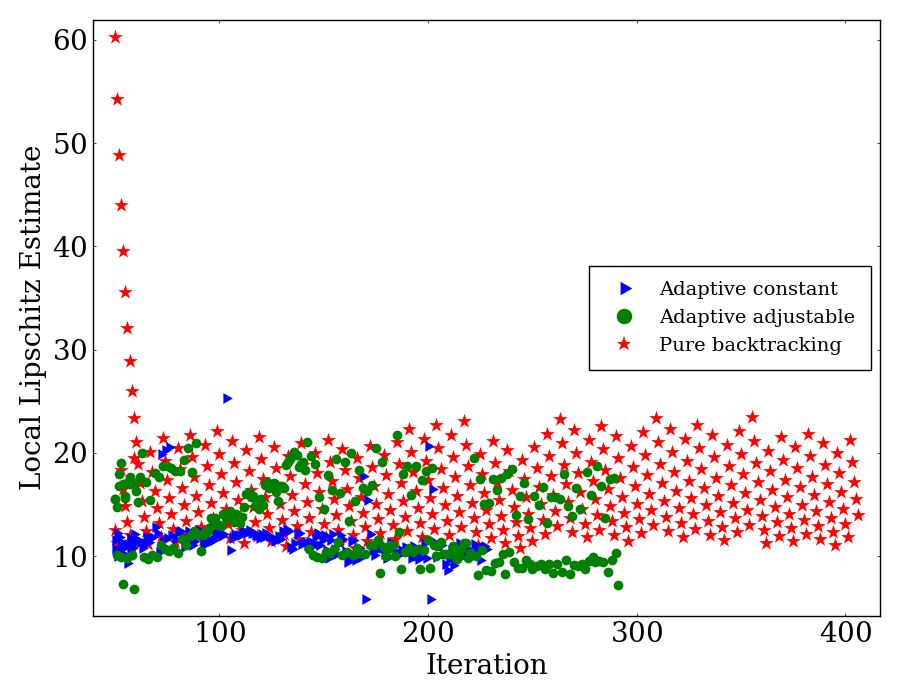

✅ Saved: Matrix_PrimalGap.eps


sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


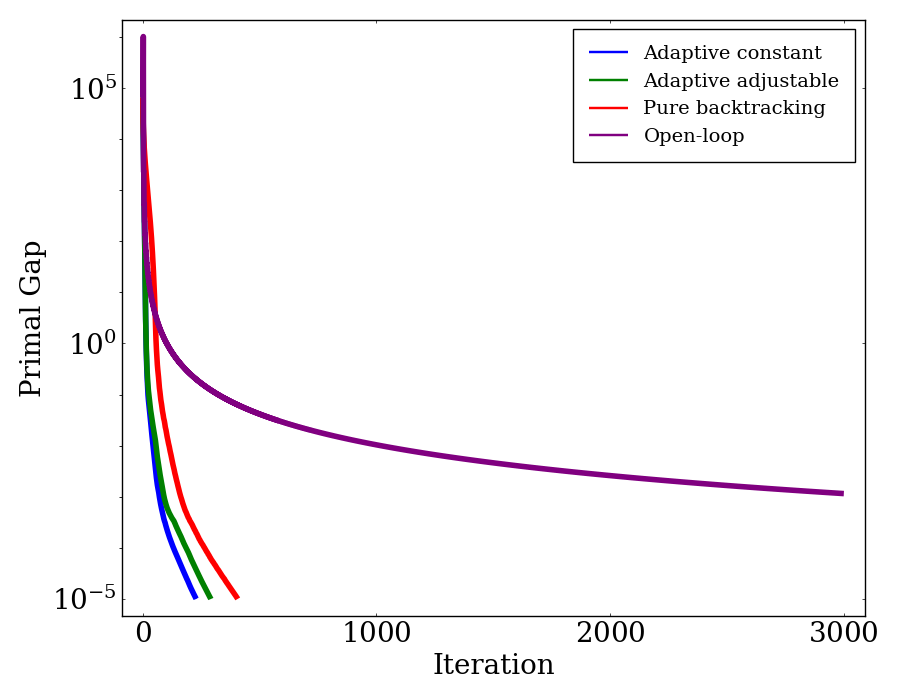

✅ Saved: Matrix_PrimalGap_vs_time.eps


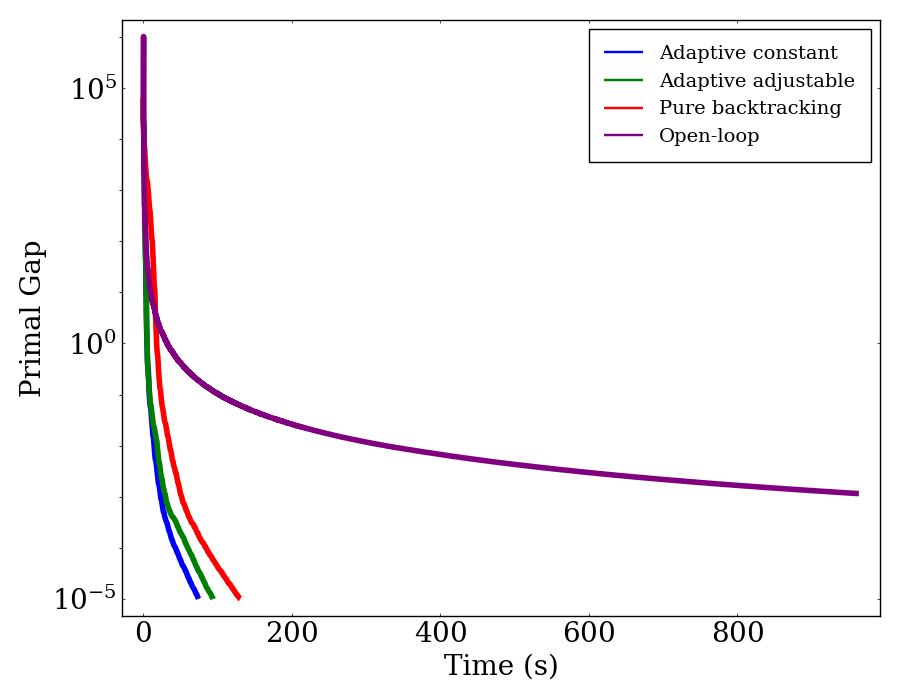


🎉 All plots saved as EPS in: /content/output


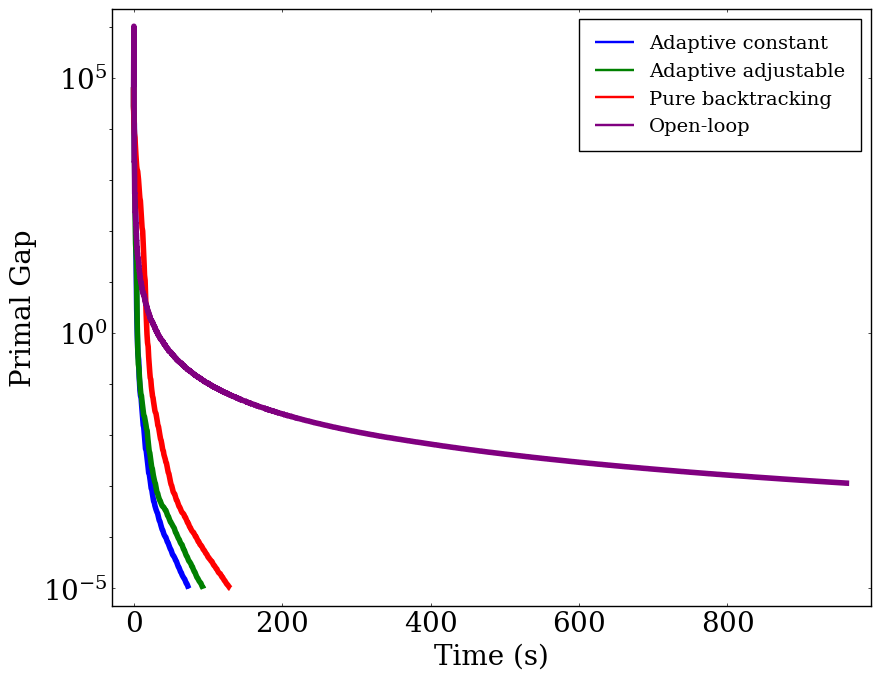

In [16]:
# Ensure all necessary packages are loaded
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using CSV
using Arpack
using SparseArrays


# ⚠️ Use PyPlot backend — works reliably in Colab and supports EPS
using PyPlot
pyplot()

output_dir = "/content/output"  # Changed to distinguish from logistic output
mkpath(output_dir)
# --- LOAD DATA ONCE ---
our = matread(joinpath(output_dir, "results_FW_OUR.mat"))
our5 = matread(joinpath(output_dir, "results_FW_OUR_5.mat"))
ped = matread(joinpath(output_dir, "results_FW_Pedregosa.mat"))
open = matread(joinpath(output_dir, "results_open.mat"))
short = matread(joinpath(output_dir, "results_L.mat"))

# --- PRINT SUMMARY TABLE ---
println("\n# Summary of Results:\n")
println("Method               Iterations    Time (s)   Objective     Dual Gap")
println("───────────────────  ──────────  ──────────  ───────────  ───────────")
# Adaptive constant
iter_our = length(our["values"]) - 1
time_our = round(sum(our["times"]), digits=2)
obj_our  = round(our["values"][end], digits=4)
gap_our  = round(our["gaps"][end], digits=4)
println(rpad("Adaptive constant", 20), lpad(iter_our, 11), "  ", lpad(time_our, 10), "  ", lpad(obj_our, 11), "  ", lpad(gap_our, 11))
# Adaptive adjustable
iter_our5 = length(our5["values"]) - 1
time_our5 = round(sum(our5["times"]), digits=2)
obj_our5  = round(our5["values"][end], digits=4)
gap_our5  = round(our5["gaps"][end], digits=4)
println(rpad("Adaptive adjustable", 20), lpad(iter_our5, 11), "  ", lpad(time_our5, 10), "  ", lpad(obj_our5, 11), "  ", lpad(gap_our5, 11))
# Pure backtracking
iter_ped = length(ped["values"]) - 1
time_ped = round(sum(ped["times"]), digits=2)
obj_ped  = round(ped["values"][end], digits=4)
gap_ped  = round(ped["gaps"][end], digits=4)
println(rpad("Pure backtracking", 20), lpad(iter_ped, 11), "  ", lpad(time_ped, 10), "  ", lpad(obj_ped, 11), "  ", lpad(gap_ped, 11))

# Open-loop
iter_open = length(open["values"]) - 1
time_open = round(sum(open["times"]), digits=2)
obj_open  = round(open["values"][end], digits=4)
gap_open  = round(open["gaps"][end], digits=4)
println(rpad("Open-loop", 20), lpad(iter_open, 11), "  ", lpad(time_open, 10), "  ", lpad(obj_open, 11), "  ", lpad(gap_open, 11))
println("\nAll computations and plotting complete. Check $output_dir for results.")




#________________________new________Ploting_______________________________________#
function create_and_save_plots()

    f_star = 480.28349931538526

        # Compute primal gaps
        our_gaps = our["values"] .- f_star
        our5_gaps = our5["values"] .- f_star
        ped_gaps = ped["values"] .- f_star
        open_gaps = open["values"] .- f_star
        short_gaps = short["values"] .- f_star
    # --- PREPARE CUMULATIVE TIMES ---
    our_cum_times = [0.0; cumsum(our["times"][1:end-1])]
    our5_cum_times = [0.0; cumsum(our5["times"][1:end-1])]
    ped_cum_times = [0.0; cumsum(ped["times"][1:end-1])]
    open_cum_times = [0.0; cumsum(open["times"][1:end-1])]
    short_cum_times = [0.0; cumsum(short["times"][1:end-1])]

    # --- STYLE DICTIONARY ---
    style = Dict(
        :titlefont => (20, "serif"),
        :guidefont => (20, "serif"),
        :tickfont => (20, "serif"),
        :legendfont => (14, "serif"),
        :grid => false,
        :framestyle => :box,
        :margin => 5mm,
        :size => (900, 700),
        :linewidth => 2
    )

    # Lipschitz Constants (p1) - Unchanged
    # --- PLOT 1: Lipschitz Constants (Legend order: Adaptive constant → Adaptive adjustable → Pedregosa) ---
    p1 = Plots.plot()  # Start with empty plot (optional, but clean)
    # 1. Plot RED first — hidden from legend (drawn underneath)
    # Lipschitz Constants (p1) - Plotting from index 40 to end with iteration starting at 40
    Plots.plot!(p1, 50:length(ped["L_ks"]), ped["L_ks"][40:end],
                label=false,                  # ← NOT in legend yet
                color=:red,
                seriestype=:scatter,
                markersize=11,
                marker=:star5,
                markerstrokewidth=0)

    # 2. Plot BLUE — appears in legend
    Plots.plot!(p1, 50:length(our["L_ks"]), our["L_ks"][40:end],
                label="Adaptive constant",
                color=:blue,
                seriestype=:scatter,
                markersize=0.1,
                marker=:rtriangle,
                markerstrokewidth=0)

    # 3. Plot GREEN — appears in legend
    Plots.plot!(p1, 50:length(our5["L_ks"]), our5["L_ks"][40:end],
                label="Adaptive adjustable",
                color=:green,
                seriestype=:scatter,
                markersize=0.1,
                marker=:circle,
                markerstrokewidth=0)

    # 4. Plot RED again — now add to legend (appears LAST in legend)
    Plots.plot!(p1, 50:length(ped["L_ks"]), ped["L_ks"][40:end],
                label="Pure backtracking",
                color=:red,
                seriestype=:scatter,
                markersize=7,
                marker=:star5,
                markerstrokewidth=0)
        # 2. Plot BLUE — appears in legend
    Plots.plot!(p1, 50:length(our["L_ks"]), our["L_ks"][40:end],
                label=false,                  # ← NOT in legend yet
                color=:blue,
                seriestype=:scatter,
                markersize=9,
                marker=:rtriangle,
                markerstrokewidth=0)

    # 3. Plot GREEN — appears in legend
    Plots.plot!(p1, 50:length(our5["L_ks"]), our5["L_ks"][40:end],
                label=false,                  # ← NOT in legend yet
                color=:green,
                seriestype=:scatter,
                markersize=7,
                marker=:circle,
                markerstrokewidth=0)

    # Set axis labels and style
    # Set axis labels, style, and LEGEND POSITION
    Plots.plot!(p1,
        xlabel="Iteration",
        ylabel="Local Lipschitz Estimate",
        legend=:right,           # ✅ FIXED: no underscore
        legend_background_color=:white,
        legend_foreground_color=:black,
       # legend_background_color=RGBA(1, 1, 1, 0.8), # Semi-transparent legend background
        framestyle=:box;
        style...)

    Plots.savefig(p1, joinpath(output_dir, "Matrix_L.eps"))
    println("✅ Saved: Matrix_L.eps")
    display(p1)

    # --- PLOT 2: primal Gap vs Iteration (Legend order: Adaptive constant → Adaptive adjustable → Pedregosa → Short → Open) ---
    p2 = Plots.plot(our_gaps[1:end],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    markersize=7,
                    yscale=:log10,
                    xlabel="Iteration",
                    ylabel="Primal Gap",
                    linewidth=4,;
                    style...)
    Plots.plot!(p2, our_gaps[1:end],
                label=false,                  # ← NOT in legend yet
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)

    Plots.plot!(p2, our5_gaps[1:end],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p2, ped_gaps[1:end],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)


    Plots.plot!(p2, open_gaps[1:end],
                    label="Open-loop",
                    color=:purple,
                    markerstrokecolor=:purple,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p2, joinpath(output_dir, "Matrix_PrimalGap.eps"))
    println("✅ Saved: Matrix_PrimalGap.eps")
    display(p2)


# --- PLOT 3: Primal Gap vs Time ---
# --- PLOT 3: Primal Gap vs Time ---
# Ensure consistent indexing for times and gaps
p3 = Plots.plot(our_cum_times[1:length(our_gaps)], our_gaps[1:end],
                label="Adaptive constant",
                color=:blue,
                markerstrokecolor=:blue,
                yscale=:log10,
                xlabel="Time (s)",
                ylabel="Primal Gap";
                style...)


Plots.plot!(our_cum_times[1:length(our_gaps)], our_gaps[1:end],
                label=false,                  # ← NOT in legend yet
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)

Plots.plot!(p3, our5_cum_times[1:length(our5_gaps)], our5_gaps[1:end],
                label="Adaptive adjustable",
                color=:green,
                markerstrokecolor=:green,
                linewidth=4,
                markersize=7)

Plots.plot!(p3, ped_cum_times[1:length(ped_gaps)], ped_gaps[1:end],
                label="Pure backtracking",
                color=:red,
                markerstrokecolor=:red,
                linewidth=4,
                markersize=7)


Plots.plot!(p3, open_cum_times[1:length(open_gaps)], open_gaps[1:end],
                label="Open-loop",
                color=:purple,
                markerstrokecolor=:purple,
                linewidth=4,
                markersize=7)


    Plots.savefig(p3, joinpath(output_dir, "Matrix_PrimalGap_vs_time.eps"))
    println("✅ Saved: Matrix_PrimalGap_vs_time.eps")
    display(p3)

    println("\n🎉 All plots saved as EPS in: $output_dir")
end

# --- RUN PLOTTING ---

create_and_save_plots()
#______________________________________________________________________________#

In [17]:
# Step 1: Ensure PyCall is installed
# This package allows Julia to call Python functions.
using Pkg
Pkg.add("PyCall")

# Step 2: Zip the output folder
# We run a shell command to compress the '/content/output' directory
# into a single file named 'output.zip'.
println("Zipping the output folder...")
try
    run(`zip -r /content/output.zip /content/output`)
    println("Zipping successful!")
catch e
    println("Error during zipping: ", e)
end


# Step 3: Download the created zip file
# We use PyCall to access Google Colab's Python library for downloading files.
println("Preparing to download...")
using PyCall

try
    # Import the Python module "google.colab.files"
    @pyimport google.colab.files as colab_files

    # Trigger the browser download for the zip file
    println("Please check your browser to confirm the download.")
    colab_files.download("/content/output.zip")
catch e
    println("Error during download: ", e)
    println("Please ensure you are running this in a Google Colab environment.")
end

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


Zipping the output folder...
  adding: content/output/ (stored 0%)
  adding: content/output/results_L.mat (deflated 21%)
  adding: content/output/data.mat (deflated 89%)
  adding: content/output/Matrix_PrimalGap.eps (deflated 63%)
  adding: content/output/Matrix_PrimalGap_vs_time.eps (deflated 64%)
  adding: content/output/Matrix_L.eps (deflated 75%)
  adding: content/output/results_FW_Pedregosa.mat (deflated 41%)
  adding: content/output/results_FW_OUR.mat (deflated 47%)
  adding: content/output/results_FW_OUR_5.mat (deflated 44%)
  adding: content/output/results_open.mat (deflated 37%)
Zipping successful!
Preparing to download...


LoadError: syntax: unsupported `const` declaration on local variable around /root/.julia/packages/PyCall/1gn3u/src/PyCall.jl:602